# Demo 4 (PS): Regression and Classification of Group Conditions in Pose Segmentation Data

*Written and last updated July 19, 2025 by Sedona Ewbank, snewbank@stanford.edu*

The purpose of this demo is to demonstrate how to classify and/or regress group conditions from pose segmentation data.

In [1]:
# A few extra imports this time for manipulating the results and viewing them!
import os
import sys
import importlib
import matplotlib.pyplot as plt
import numpy as np

#This block only important for running as script
#script_dir = os.path.dirname(os.path.abspath(__file__))
mariposa_dir = "/Users/snewbank/PycharmProjects/MARIPoSA"
utils_dir = os.path.join(mariposa_dir, 'utils')
sys.path.append(utils_dir)
sys.path.append(mariposa_dir)

#import utils
from utils import metadata, analyze, plot, simulate

importlib.reload(metadata)
importlib.reload(analyze)
importlib.reload(plot)
importlib.reload(simulate)

<module 'utils.simulate' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py'>

In [2]:
demo_dir="/Users/snewbank/Behavior/MARIPoSA_demo_data/"
config=metadata.load_project(demo_dir+"250719_test/config_PS.yaml")
save=True
save_path = demo_dir+"demo_figures/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

## 4.1: Classification
There are two main functions of interest to us here: analyze.classify() and analyze.loocv(). analyze.classify does classification by the desired method based on the entire dataset (only really recommended if the classifier is to be used on additional held-out data), and analyze.loocv does cross-validation of a classification method via leave-one-out cross-validation and gives the prediction for every sample when it is held out (useful for conveying the classification results).

In [3]:
help(analyze.classify)
help(analyze.loocv)

Help on function classify in module utils.analyze:

classify(module_feature_object, method='lda')
    Classify pose segmentation data using either module usage or transitions
    
    :param module_feature_object: ModuleUsage or ModuleTransitions object
    :param method: classification method to use; options include "lda", "logisticregression", "mlp", "naivebayes", "knn", or "randomforest"
    :return: classifier

Help on function loocv in module utils.analyze:

loocv(module_feature_object, method='lda')
    Perform leave-one-out cross-validation for a method of classifying pose segmentation data using either module usage or transitions
    
    :param module_feature_object: ModuleUsage or ModuleTransitions object
    :param method: classification method to use; options include "lda", "logisticregression", "mlp", "naivebayes", "knn", or "randomforest"
    :return: accuracy, conf_mat



In [4]:
labels_df = analyze.get_module_labels(config, 0, 1200, subgroups = ["sal","k1","k5","k10"])
module_usage = analyze.get_module_usage(config, labels_df, binsize=300)
module_usage = module_usage.scale()

accuracy, conf_mat = analyze.loocv(module_usage,method="logisticregression")
    
print(f"Logistic regression LOOCV accuracy: \n{accuracy}")
print(f"Logistic regression LOOCV confusion matrix: \n{conf_mat}")

if save:
    plt.savefig(save_path+"demo4-1_LR-confmat.png")

Logistic regression LOOCV accuracy: 
0.7692307692307693
Logistic regression LOOCV confusion matrix: 
[[6. 1. 0. 0.]
 [5. 1. 0. 0.]
 [0. 0. 6. 0.]
 [0. 0. 0. 7.]]


<Figure size 640x480 with 0 Axes>

LogisticRegression


LDA
MLP


NaiveBayes
KNN
RandomForest


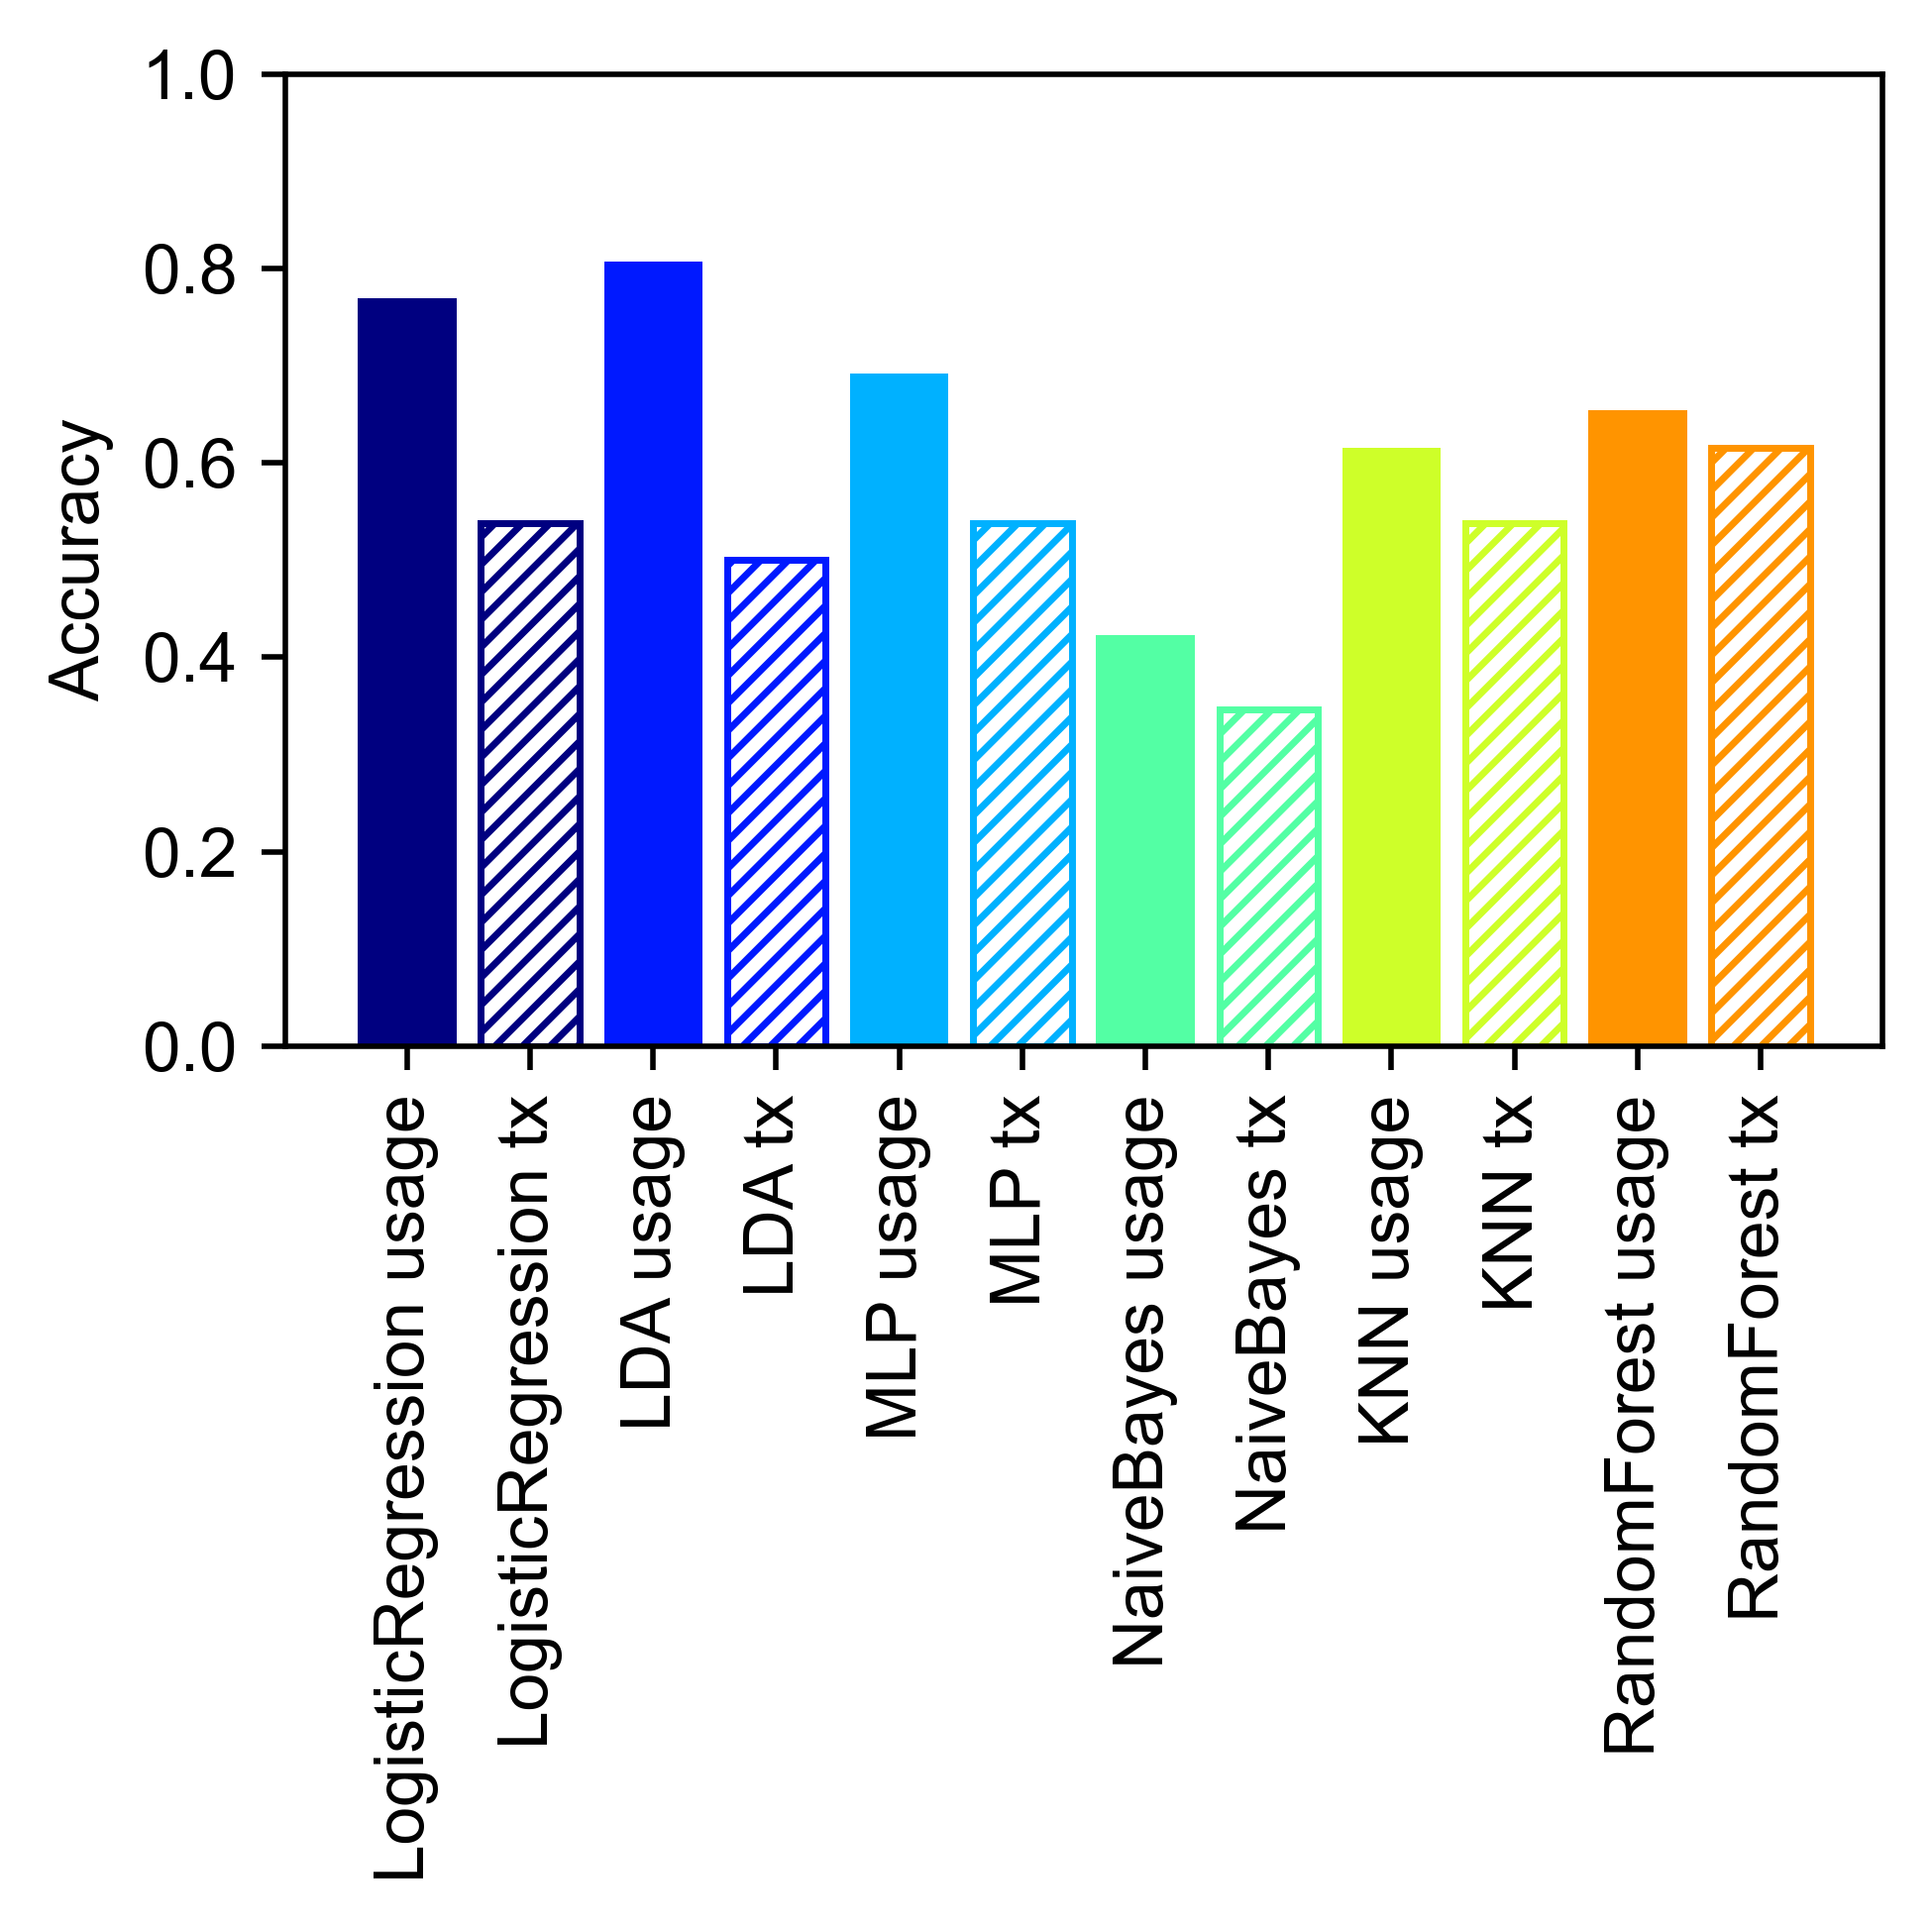

In [5]:
method_acc = {}
method_cmat = {}

labels_df = analyze.get_module_labels(config, 0, 1200, subgroups = ["sal","k1","k5","k10"])
module_usage = analyze.get_module_usage(config, labels_df, binsize=300)
module_usage = module_usage.scale()
module_transitions = analyze.get_module_transitions(config, labels_df)
module_transitions = module_transitions.scale()

for method in ["LogisticRegression","LDA","MLP","NaiveBayes","KNN","RandomForest"]:
    print(method)
    method_acc[method+" usage"], method_cmat[method+" usage"] = analyze.loocv(module_usage,method=method)
    clf = analyze.classify(module_usage,method=method)
    method_acc[method+" tx"], method_cmat[method+" tx"] = analyze.loocv(module_transitions,method=method)
    clf = analyze.classify(module_transitions,method=method)
    
xticks=[]
xticklabels=[]
jet = plt.get_cmap("jet")
colors=[jet([i]) for i in np.arange(0,1,0.15)]
plt.figure(figsize=(4,4),dpi=500)
for k,key in enumerate(list(method_acc.keys())):
    if " usage" in key:
        alpha=0.5
        plt.bar(k,method_acc[key],color=colors[int(np.trunc(k/2))])
    else:
        plt.bar(k,method_acc[key],edgecolor=colors[int(np.trunc(k/2))],color="none",hatch="//////")
    xticks.append(k)
    xticklabels.append(key)
plt.xticks(xticks,labels=xticklabels,rotation=90)
plt.ylabel("Accuracy")
plt.ylim([0,1])
plt.tight_layout()
if save:
    plt.savefig(save_path+"demo4-1_classif_compare.png")

## 4.2: Regression

If your classes actually correspond to a continuous variable (e.g., doses of a drug or stimulus intensity), it could be more informative to do regression as opposed to classification. We can do this using the analyze.regress and analyze.loocv_regression functions, and the only thing we need to add is a dictionary (dose_dict) relating our string subgroup names to the corresponding intensity/dose.

In [6]:
help(analyze.regress)
help(analyze.loocv_regression)

Help on function regress in module utils.analyze:

regress(module_feature_object, dose_dict, method='LinearRegression', degree=1, alpha=1)
    Regress a continuous variable (e.g., dose, stimulus value) from a module or keypoint feature object
    
    :param module_feature_object: ModuleUsage, ModuleTransitions, or KeypointFeature object
    :param dose_dict: dictionary with keys corresponding to subgroups and items corresponding to variable
    :param method: method of regression; either "LinearRegression" (default) or "Ridge" or "Lasso"
    :param degree: polynomial degree; default 1
    :param alpha: alpha (default 1; only applies for regularized regression, i.e. Ridge and Lasso)
    :return: regression model, dose_labels

Help on function loocv_regression in module utils.analyze:

loocv_regression(module_feature_object, dose_dict, method='LinearRegression', constrain_pos=True, degree=1, alpha=1)
    Perform LOOCV for linear regression
    
    :param module_feature_object: ModuleUs

Linear Regression
RMSE=1.99


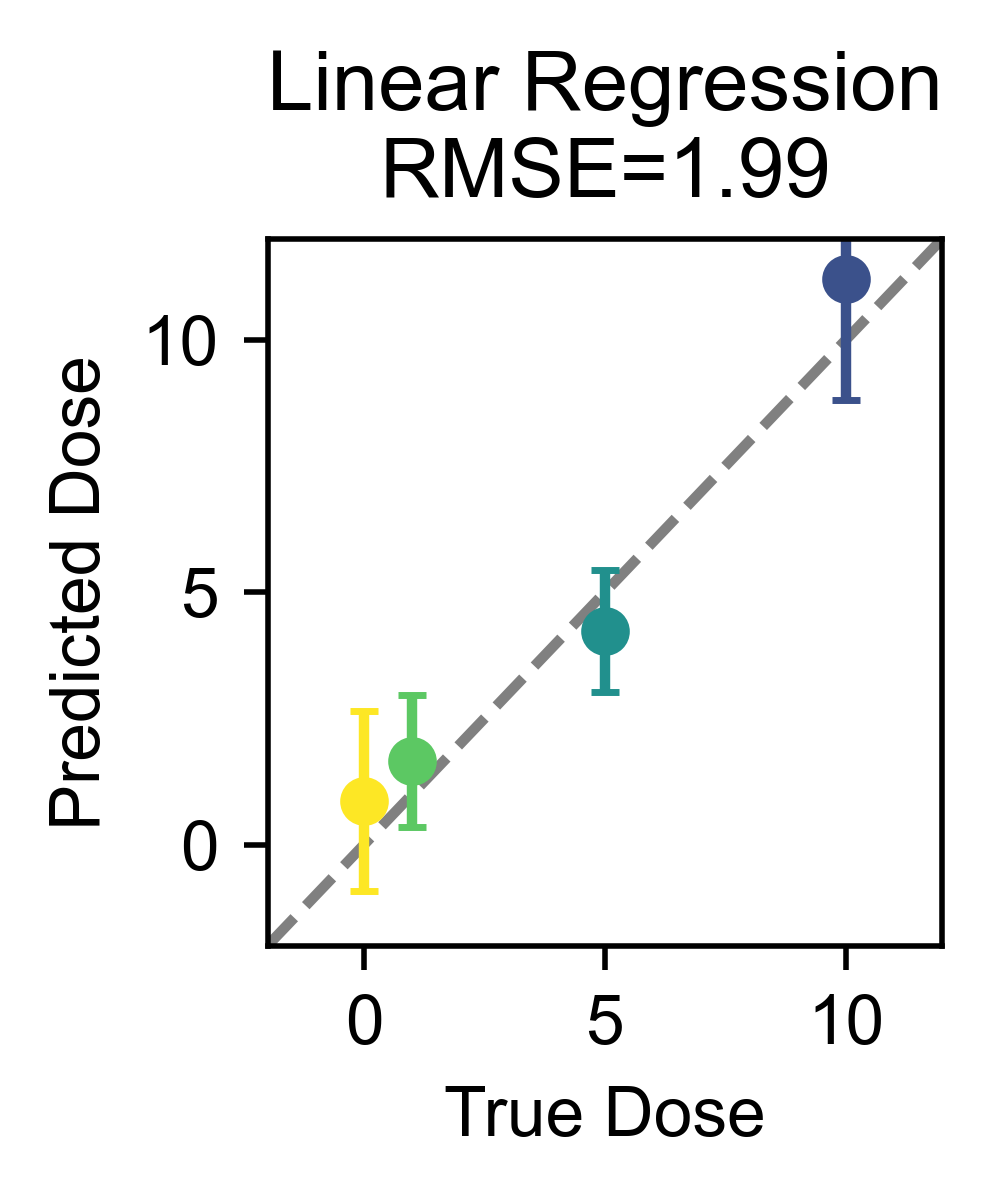

In [7]:
dose_dict={'sal': 0, 'k1': 1, 'k5': 5, 'k10': 10}

labels_df = analyze.get_module_labels(config,0,1200,subgroups=["sal","k1","k5","k10"])
all_module_usage = analyze.get_module_usage(config, labels_df)
all_module_usage = all_module_usage.scale()

cmap = plt.get_cmap("viridis_r")

fig = plt.figure(figsize=(2.2,2.5),dpi=500)
plt.xlabel("True Dose")
plt.ylabel("Predicted Dose")
plt.ylim([-2,12])
plt.xlim([-2,12])
plt.axline([0,0],[1,1],linestyle="dashed",color="gray")
reg, dose_labels = analyze.regress(all_module_usage,dose_dict,method="LinearRegression")
y_hat = reg.predict(all_module_usage.label_counts)
loocv_preds, sq_err = analyze.loocv_regression(all_module_usage,dose_dict,method="LinearRegression")
dose_cats = np.unique(dose_labels)
colors = [cmap([i]) for i in np.arange(0,1,1/len(dose_cats))]
for d, do in enumerate(dose_cats):
    y_d_hat = loocv_preds[dose_labels==do]
    plt.errorbar(do,np.mean(y_d_hat),yerr=np.std(y_d_hat),marker="o",capsize=2,color=colors[d])
rmse=np.sqrt(np.mean(sq_err))
plt.title(f'Linear Regression\nRMSE={rmse:.2f}')
print(f'Linear Regression\nRMSE={rmse:.2f}')
plt.tight_layout()
if save:
    plt.savefig(save_path+"demo4-2_linear_regression.png")

As with classification, we can use various approaches (here, linear regression with no regularization or with lasso or ridge regularization with the alpha set) and compare their performance on each of module usage and transitions.

Usage LinearRegression, alpha nan RMSE: 1.53
Usage Lasso, alpha 0.1 RMSE: 1.75
Usage Lasso, alpha 0.5 RMSE: 1.88
Usage Ridge, alpha 0.1 RMSE: 1.53
Usage Ridge, alpha 0.5 RMSE: 1.52
Tx LinearRegression, alpha nan RMSE: 1.30


Tx Lasso, alpha 0.1 RMSE: 1.45
Tx Lasso, alpha 0.5 RMSE: 1.98
Tx Ridge, alpha 0.1 RMSE: 1.30
Tx Ridge, alpha 0.5 RMSE: 1.30


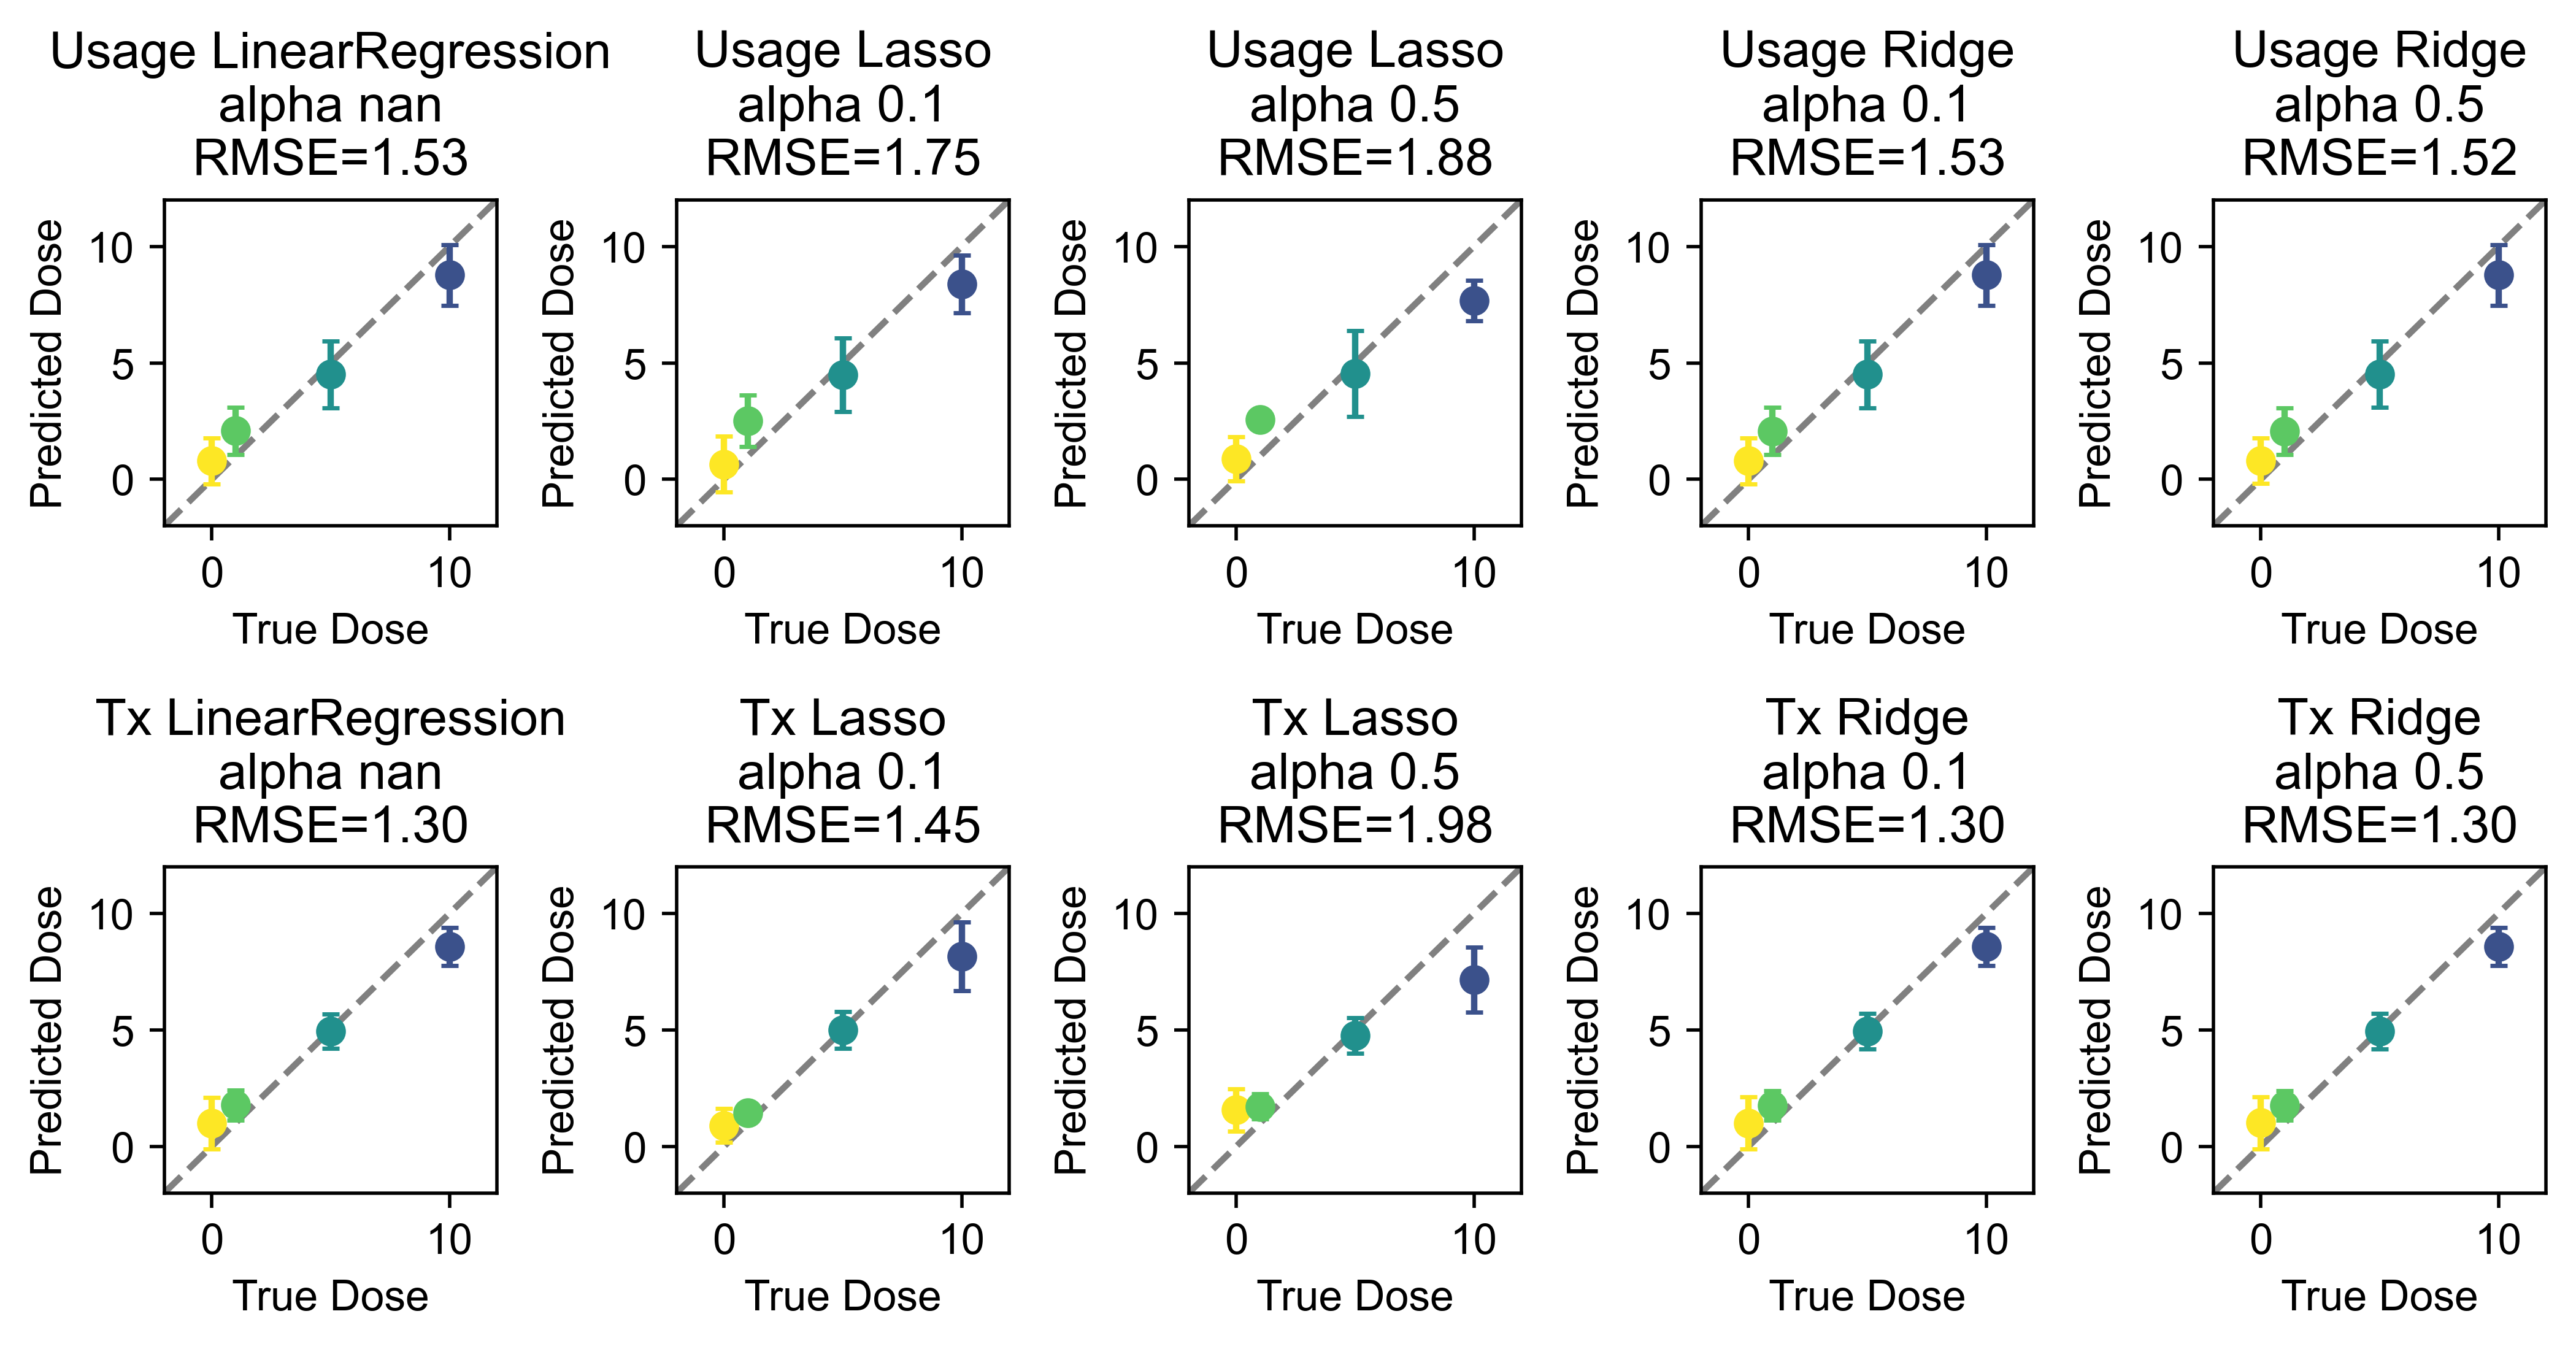

In [8]:
dose_dict={'sal': 0, 'k1': 1, 'k5': 5, 'k10': 10}

labels_df = analyze.get_module_labels(config,0,1200,subgroups=["sal","k1","k5","k10"])
all_module_usage = analyze.get_module_usage(config, labels_df,binsize=300)
all_module_usage = all_module_usage.scale()
all_module_tx = analyze.get_module_transitions(config, labels_df)
all_module_tx = all_module_tx.scale()

cmap = plt.get_cmap("viridis_r")
fig, ax = plt.subplots(2,5,figsize=(8.5,4.5),dpi=500)
for d,dat in enumerate(["Usage","Tx"]):
    for m,method in enumerate([["LinearRegression",np.nan],["Lasso",0.1],["Lasso",0.5],["Ridge",0.1],["Ridge",0.5]]):
        ax[d,m].set_xlabel("True Dose")
        ax[d,m].set_ylabel("Predicted Dose")
        ax[d,m].set_ylim([-2,12])
        ax[d,m].set_xlim([-2,12])
        ax[d,m].axline([0,0],[1,1],linestyle="dashed",color="gray")
        if dat=="Usage":
            reg, dose_labels = analyze.regress(all_module_usage,dose_dict,method=method[0],alpha=method[1])
            y_hat = reg.predict(all_module_usage.label_counts)
            loocv_preds, sq_err = analyze.loocv_regression(all_module_usage,dose_dict,method=method[0],alpha=method[1])
        elif dat=="Tx":
            reg, dose_labels = analyze.regress(all_module_tx,dose_dict,method=method[0],alpha=method[1])
            y_hat = reg.predict(all_module_tx.transition_counts)
            loocv_preds, sq_err = analyze.loocv_regression(all_module_tx,dose_dict,method=method[0],alpha=method[1])
        dose_cats = np.unique(dose_labels)
        colors = [cmap([i]) for i in np.arange(0,1,1/len(dose_cats))]
        for do, dose in enumerate(dose_cats):
            y_d_hat = loocv_preds[dose_labels==dose]
            ax[d,m].errorbar(dose,np.mean(y_d_hat),yerr=np.std(y_d_hat),marker="o",capsize=2,color=colors[do])
        rmse=np.sqrt(np.mean(sq_err))
        ax[d,m].set_title(f'{dat} {method[0]}\nalpha {method[1]}\nRMSE={rmse:.2f}')
        print(f'{dat} {method[0]}, alpha {method[1]} RMSE: {rmse:.2f}')
plt.tight_layout()
if save:
    plt.savefig(save_path+"demo4-2_regression_bymethod.png",dpi=500)